---

<h1 style="text-align: center;"><strong>Projeto de Regressão Linear</strong></h1>
<h2 style="text-align: center;"><strong>Previsão de vendas globais de video games</strong></h2>

---

**Objetivo do projeto:** desenvolver um projeto de regressão linear com uma base pública e real,
documentando as decisões de preparação dos dados, modelagem, avaliação e comunicação dos
resultados, com aplicação interativa em Streamlit.


## 3.1. Proposição do problema

**Pergunta de pesquisa:**
> Em que medida a nota da crítica especializada, a nota dos usuários, o gênero e a plataforma
> ajudam a explicar as vendas globais de um video game?

**Variável resposta (y):** `Global_Sales`, que são as vendas globais do jogo em milhões de unidades (variável numérica
contínua).

**Variáveis explicativas candidatas (X):**
| Variável | Tipo | Unidade | Descrição |
|---|---|---|---|
| `Critic_Score` | Numérica contínua | Escala 0–100 | Nota agregada da crítica especializada (Metacritic) |
| `User_Score` | Numérica contínua | Escala 0–10 | Nota agregada dos usuários (Metacritic) |
| `Genre` | Categórica nominal | — | Gênero do jogo (Action, Sports, RPG etc.) |
| `Platform` | Categórica nominal | — | Plataforma de lançamento (PS4, Wii, X360 etc.) |
| `Year_of_Release` | Numérica discreta | Ano | Ano de lançamento do jogo |

**Justificativa da relevância do problema:** o mercado de video games movimenta bilhões de
dólares por ano, e publishers/desenvolvedoras precisam decidir onde investir marketing e em
quais plataformas lançar um título. Entender quais fatores estão associados a maiores vendas
apoia decisões de negócio nesse mercado.

**Hipóteses iniciais do grupo:**
1. Jogos com nota de crítica mais alta tendem a vender mais (associação positiva entre
   `Critic_Score` e `Global_Sales`).
2. A nota dos usuários (`User_Score`) tem relação mais fraca com vendas do que a nota da
   crítica, pois a nota do usuário é dada *depois* da compra, enquanto a crítica influencia a
   decisão de compra.
3. Certos gêneros (ex.: Action, Sports) têm volume de vendas médio maior do que gêneros de nicho
   (ex.: Puzzle, Strategy).
4. O efeito da nota da crítica sobre as vendas não é necessariamente linear. Jogos "muito bem
   avaliados" (ex. nota > 90) podem vender desproporcionalmente mais (hipótese que motiva testar
   um termo polinomial mais adiante).

> *As hipóteses acima serão retomadas e confrontadas com os resultados na seção de conclusão.*


## 3.2. Origem e documentação dos dados

- **Nome da base:** Video Game Sales with Ratings
- **Fonte:** Kaggle (usuário Rush Kirubi), com vendas originalmente coletadas pelo VGChartz e
  notas de crítica/usuário agregadas do Metacritic.
- **Endereço de acesso:** https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings
- **Data de acesso:** 24/08/2026
- **Quantidade inicial:** 16.719 linhas × 16 colunas
- **Unidade de observação:** um título de jogo lançado em uma plataforma específica (o mesmo
  jogo lançado em duas plataformas conta como duas linhas).
- **Licença/condições de uso:** dataset público disponibilizado no Kaggle para fins educacionais
  e de pesquisa.

### Dicionário de dados (colunas originais)

| Variável | Tipo | Unidade/categorias | Descrição |
|---|---|---|---|
| `Name` | Texto | — | Nome do jogo |
| `Platform` | Categórica nominal | Categorias | Plataforma de lançamento |
| `Year_of_Release` | Numérica discreta | Ano | Ano de lançamento |
| `Genre` | Categórica nominal | Categorias | Gênero do jogo |
| `Publisher` | Categórica nominal | Categorias | Empresa publicadora |
| `NA_Sales` | Numérica contínua | Milhões de unidades | Vendas na América do Norte |
| `EU_Sales` | Numérica contínua | Milhões de unidades | Vendas na Europa |
| `JP_Sales` | Numérica contínua | Milhões de unidades | Vendas no Japão |
| `Other_Sales` | Numérica contínua | Milhões de unidades | Vendas no resto do mundo |
| `Global_Sales` | Numérica contínua | Milhões de unidades | **Variável resposta**: vendas globais |
| `Critic_Score` | Numérica contínua | Escala 0–100 | Nota agregada da crítica (Metacritic) |
| `Critic_Count` | Numérica discreta | Contagem | Número de críticos que avaliaram |
| `User_Score` | *Armazenada como texto* | Escala 0–10 | Nota agregada dos usuários (Metacritic) |
| `User_Count` | Numérica discreta | Contagem | Número de usuários que avaliaram |
| `Developer` | Categórica nominal | Categorias | Estúdio desenvolvedor |
| `Rating` | Categórica nominal | Categorias | Classificação etária ESRB (E, T, M etc.) |


**O que vamos fazer aqui:** importar as bibliotecas que vamos usar no projeto inteiro e
carregar o CSV bruto (sem nenhum tratamento ainda) num DataFrame chamado `df_bruto`, que vamos
manter intocado ao longo de todo o notebook para servir de comparação com a base tratada.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Leitura dos dados brutos
df_bruto = pd.read_csv('dados/vgsales_bruto.csv')

print(f'Dimensões do DataFrame: {df_bruto.shape}')
df_bruto.head()

Dimensões do DataFrame: (16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


**O que vamos fazer aqui:** olhar o tipo de dado (`dtype`) de cada coluna e quantos valores não
nulos ela tem. É o primeiro raio-x da base, que já vai apontar pistas do que precisa ser
corrigido na seção de data wrangling (ex.: colunas numéricas que vieram como texto, e colunas com
muitos valores ausentes).


In [2]:
# Visão geral dos tipos de dados e valores não nulos
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 3.0 MB


## 3.3. Data wrangling

Nesta seção investigamos e tratamos, de forma explícita e reprodutível, os problemas
identificados na base bruta. Partimos de uma cópia (`df`) para preservar `df_bruto` intacto
como referência de comparação no fechamento da seção.

### Problemas identificados (diagnóstico)

1. **Registros duplicados:** 2 pares de jogos com mesmo nome/plataforma/ano e mesmos metadados
   de crítica, mas vendas muito diferentes entre si (indício de lançamento duplicado com entrada
   residual/errada).
2. **Valores ausentes:** presentes em várias colunas, com destaque para `Critic_Score` (8.582),
   `User_Score`/`User_Count` (6.704/9.129) e `Developer`/`Rating` (~6.700 cada).
3. **Número armazenado como texto:** `User_Score` é lido como texto porque contém o valor
   `"tbd"` ("to be determined") misturado com números.
4. **Valor impossível ou incoerente:** 4 jogos com `Year_of_Release` posterior a 2016, ano em
   que esta base foi compilada (um deles com ano 2020). É erro de registro, não uma característica
   legítima dos dados.
5. **Categorias escritas de formas diferentes:** `Rating` contém o código legado `K-A`
   (usado até 1998), que corresponde à categoria atual `E`.
6. **Categoria não informativa:** `Rating = "RP"` significa "classificação pendente", ou seja,
   ausência de classificação, não uma classificação em si.
7. **Variável sem utilidade preditiva:** `Name` identifica o jogo, mas não deve entrar como
   preditor (seria só um proxy para o índice da linha). Será mantida apenas para leitura humana
   e removida na etapa de modelagem.

Cada um dos pontos acima é tratado separadamente a seguir, com o motivo da escolha registrado
em comentário.


**O que vamos fazer aqui:** criar uma cópia de trabalho (`df`) a partir de `df_bruto`. Todo o
tratamento a seguir será feito nessa cópia, para que a base original continue disponível como
referência de comparação no fechamento da seção (3.3.7).


In [3]:
# Trabalhamos sobre uma cópia para preservar a base bruta como referência de comparação
df = df_bruto.copy()
print(f'Dimensões antes do tratamento: {df.shape}')

Dimensões antes do tratamento: (16719, 16)


### 3.3.1. Tratamento de registros duplicados

**O que vamos fazer aqui:** primeiro checar duplicados considerando a linha inteira (nenhum
esperado, pois cada linha tem colunas de venda diferentes na prática), e depois checar duplicados
por uma chave mais realista de identidade do jogo (nome, plataforma e ano de lançamento), que é
o que de fato identifica um "mesmo lançamento" nesta base.


In [4]:
# Duplicados considerando a linha inteira: nenhum encontrado
print(f'Duplicados (linha inteira): {df.duplicated().sum()}')

# Duplicados considerando a chave de identidade do jogo (nome + plataforma + ano de lançamento)
chave = ['Name', 'Platform', 'Year_of_Release']
duplicados_chave = df[df.duplicated(subset=chave, keep=False)].sort_values(chave)
duplicados_chave

Duplicados (linha inteira): 0


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
604,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,2.11,0.22,0.00,0.23,2.56,83.0,22.0,5.5,101.0,EA Tiburon,E
16233,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01,83.0,22.0,5.5,101.0,EA Tiburon,E
659,NaN,GEN,1993.0,NaN,Acclaim Entertainment,1.78,0.53,0.00,0.08,2.39,NaN,NaN,NaN,NaN,NaN,NaN
14246,NaN,GEN,1993.0,NaN,Acclaim Entertainment,0.00,0.00,0.03,0.00,0.03,NaN,NaN,NaN,NaN,NaN,NaN


**O que vamos fazer aqui:** aplicar a decisão de tratamento definida acima. Para cada par
duplicado, ficamos só com a linha de maior `Global_Sales` (o lançamento "principal") e
descartamos a outra.


In [5]:
# Decisão: para cada par duplicado, mantemos apenas o registro com MAIOR Global_Sales
# (representa o lançamento "principal"; o registro com vendas muito menores é tratado como
# entrada residual/errada do mesmo título, já que todos os demais metadados são idênticos).
df = df.sort_values('Global_Sales', ascending=False).drop_duplicates(subset=chave, keep='first')

print(f'Duplicados removidos. Dimensões agora: {df.shape}')
assert df.duplicated(subset=chave).sum() == 0

Duplicados removidos. Dimensões agora: (16717, 16)


### 3.3.2. `User_Score`: número armazenado como texto

**O que vamos fazer aqui:** contar quantas linhas têm o valor `"tbd"` em `User_Score`,
substituir esse valor por ausente (`NaN`) e converter a coluna inteira de texto para número
decimal (`float`), para que ela possa ser usada em cálculos e no modelo.


In [6]:
# 'tbd' (to be determined) indica nota ainda não disponível: tratamos como ausente (NaN),
# e então convertemos a coluna inteira para numérico.
print('Valores não numéricos encontrados:', df.loc[df['User_Score'] == 'tbd', 'User_Score'].count())

df['User_Score'] = df['User_Score'].replace('tbd', np.nan).astype(float)
print(f'Novo tipo de User_Score: {df["User_Score"].dtype}')
df['User_Score'].describe()

Valores não numéricos encontrados: 2425
Novo tipo de User_Score: float64


count    7589.000000
mean        7.125260
std         1.499989
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: User_Score, dtype: float64

### 3.3.3. `Year_of_Release`: valores incoerentes

**O que vamos fazer aqui:** listar os jogos com ano de lançamento posterior a 2016 (impossível,
já que a base foi compilada nesse ano) e substituir esses valores por ausente. Não removemos a
linha inteira, porque as outras colunas dela continuam válidas e úteis.


In [7]:
# Esta base foi compilada em dezembro/2016; anos de lançamento posteriores a 2016
# são, portanto, erros de registro (não podemos inferir o ano correto), e são marcados como
# ausentes em vez de removidos, preservando o restante da informação de cada linha.
anos_invalidos = df[df['Year_of_Release'] > 2016]
print('Registros com ano de lançamento inválido (> 2016):')
print(anos_invalidos[['Name', 'Platform', 'Year_of_Release']])

df.loc[df['Year_of_Release'] > 2016, 'Year_of_Release'] = np.nan

Registros com ano de lançamento inválido (> 2016):
                                                   Name Platform  \
5936                             Imagine: Makeup Artist       DS   
14086  Phantasy Star Online 2 Episode 4: Deluxe Package      PS4   
16222  Phantasy Star Online 2 Episode 4: Deluxe Package      PSV   
16385                  Brothers Conflict: Precious Baby      PSV   

       Year_of_Release  
5936            2020.0  
14086           2017.0  
16222           2017.0  
16385           2017.0  


### 3.3.4. `Rating`: categorias escritas de formas diferentes

**O que vamos fazer aqui:** ver a contagem de cada categoria de `Rating` antes de mexer em
nada, unificar `K-A` (nome antigo) dentro de `E` (nome atual da mesma classificação), tratar
`RP` como ausente (já que "pendente" não é uma classificação de fato), e conferir a contagem
depois da mudança.


In [8]:
# 'K-A' (Kids to Adults) é o nome antigo da classificação hoje chamada 'E' (Everyone),
# usado pela ESRB até 1998: consolidamos as duas grafias em uma única categoria.
# 'RP' (Rating Pending) não é uma classificação em si, e sim ausência de classificação:
# tratamos como valor ausente.
print('Antes:')
print(df['Rating'].value_counts(dropna=False))

df['Rating'] = df['Rating'].replace({'K-A': 'E', 'RP': np.nan})

print('\nDepois:')
print(df['Rating'].value_counts(dropna=False))

Antes:
Rating
NaN     6768
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64

Depois:
Rating
NaN     6771
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: count, dtype: int64


### 3.3.5. Valores ausentes

**O que vamos fazer aqui:** recontar os valores ausentes por coluna (já refletindo as
correções anteriores; por exemplo, `User_Score` agora tem mais ausentes do que na base bruta,
porque convertemos "tbd" em `NaN`) e, a partir disso, decidir coluna a coluna o que fazer.


In [9]:
# Contagem de ausentes por coluna, após as correções anteriores
df.isnull().sum().sort_values(ascending=False)

User_Score         9128
User_Count         9128
Critic_Score       8581
Critic_Count       8581
Rating             6771
Developer          6622
Year_of_Release     273
Publisher            54
Name                  1
Genre                 1
NA_Sales              0
Platform              0
JP_Sales              0
EU_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

**Estratégia adotada, coluna a coluna:**

- **`Name` e `Genre` (2 ausentes cada, na base original, nas mesmas 2 linhas):** essas 2 linhas
  correspondem exatamente ao par duplicado do jogo sem nome da Acclaim (GEN, 1993) tratado na
  seção 3.3.1. Como uma das duas já foi removida ali, resta apenas 1 linha órfã com `Name` e
  `Genre` ausentes, que é removida agora. É uma fração irrelevante da base (0,006%) e não há como
  recuperar a informação.
- **`Critic_Score`, `Critic_Count`, `User_Score`, `User_Count`:** ausência em torno de 40 a 55%
  dos registros. Optamos por **não imputar** esses valores (preencher artificialmente notas de
  crítica/usuário poderia distorcer exatamente a relação que queremos investigar). Em vez disso,
  as linhas sem essas notas simplesmente não entram no treino/teste do modelo quando essas
  variáveis forem usadas como preditoras. Essa decisão será aplicada na seção 3.5.
- **`Publisher`, `Developer`, `Rating`, `Year_of_Release`:** não fazem parte do conjunto
  principal de preditores deste estudo. Os valores ausentes são mantidos como estão e não afetam
  a modelagem final.


**O que vamos fazer aqui:** aplicar a única remoção de linha decidida acima (a linha órfã sem
`Name`/`Genre`) e conferir quantas linhas realmente saíram.


In [10]:
linhas_antes = df.shape[0]
df = df.dropna(subset=['Name', 'Genre'])
print(f'Linhas removidas por Name/Genre ausentes: {linhas_antes - df.shape[0]}')
print(f'Dimensões agora: {df.shape}')

Linhas removidas por Name/Genre ausentes: 1
Dimensões agora: (16716, 16)


### 3.3.6. Variável sem utilidade preditiva

`Name` identifica unicamente cada jogo (praticamente um valor distinto por linha) e, por isso,
não carrega poder explicativo generalizável para um modelo de regressão. Não faria sentido
"aprender" um coeficiente para cada nome de jogo. Mantemos a coluna no `df` apenas para leitura
humana (ex.: identificar exemplos nos gráficos), mas ela **não** entrará como variável
explicativa; essa exclusão é retomada e justificada formalmente na seção 3.5
(Preparação para a modelagem).


### 3.3.7. Fechamento: comparação com a base original

**O que vamos fazer aqui:** comparar as dimensões de `df_bruto` (intocado desde o início) com
as de `df` (depois de todo o tratamento desta seção), e resumir em texto tudo o que mudou,
fechando a seção de data wrangling de forma auditável.


In [11]:
print('Base original (df_bruto):', df_bruto.shape)
print('Base tratada       (df):     ', df.shape)
print()
print(f'Linhas removidas: {df_bruto.shape[0] - df.shape[0]} '
      f'({(df_bruto.shape[0] - df.shape[0]) / df_bruto.shape[0]:.2%} da base original)')
print('Colunas removidas: 0 (nenhuma coluna foi excluída nesta etapa)')
print()
print('Resumo do que mudou:')
print('- 2 registros duplicados removidos (Madden NFL 13 / jogo GEN sem nome)')
print('- 1 registro remanescente com Name/Genre ausentes removido')
print('- User_Score convertido de texto para numérico ("tbd" -> ausente)')
print('- 4 valores de Year_of_Release corrigidos para ausente (anos posteriores a 2016)')
print('- Rating: "K-A" consolidado em "E"; "RP" tratado como ausente')

Base original (df_bruto): (16719, 16)
Base tratada       (df):      (16716, 16)

Linhas removidas: 3 (0.02% da base original)
Colunas removidas: 0 (nenhuma coluna foi excluída nesta etapa)

Resumo do que mudou:
- 2 registros duplicados removidos (Madden NFL 13 / jogo GEN sem nome)
- 1 registro remanescente com Name/Genre ausentes removido
- User_Score convertido de texto para numérico ("tbd" -> ausente)
- 4 valores de Year_of_Release corrigidos para ausente (anos posteriores a 2016)
- Rating: "K-A" consolidado em "E"; "RP" tratado como ausente


## 3.4. Análise exploratória

Cada gráfico desta seção responde a uma pergunta específica de análise, tem título, eixos
identificados com unidade, e é seguido de uma interpretação escrita.


### 3.4.1. Estatísticas descritivas da variável resposta

**O que vamos fazer aqui:** calcular as estatísticas-resumo (`describe()`) de `Global_Sales`,
ou seja, média, mediana, desvio-padrão, mínimo e máximo, e também a assimetria (skewness), para
já entender a forma da distribuição antes mesmo de plotar qualquer gráfico.


In [12]:
from scipy.stats import skew

desc = df['Global_Sales'].describe()
print(desc)
print(f'\nAssimetria (skewness): {skew(df["Global_Sales"]):.2f}')

count    16716.000000
mean         0.533493
std          1.547997
min          0.010000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.530000
Name: Global_Sales, dtype: float64

Assimetria (skewness): 17.38


**Interpretação:** a média (0,53 milhão de unidades) é muito maior que a mediana (0,17 milhão),
e a assimetria é fortemente positiva (coeficiente ≈ 17,4, bem acima do que se considera
"moderadamente assimétrico", que já seria acima de 1). Isso indica que a maioria dos jogos vende
pouco, enquanto poucos títulos (como "Wii Sports", com 82,53 milhões de unidades) puxam a média
para cima, um padrão comum em mercados dominados por "hits". Essa assimetria será retomada na
discussão de não linearidade ao final da seção.


### 3.4.2. Distribuição da variável resposta

**Pergunta:** como as vendas globais estão distribuídas entre os jogos da base?

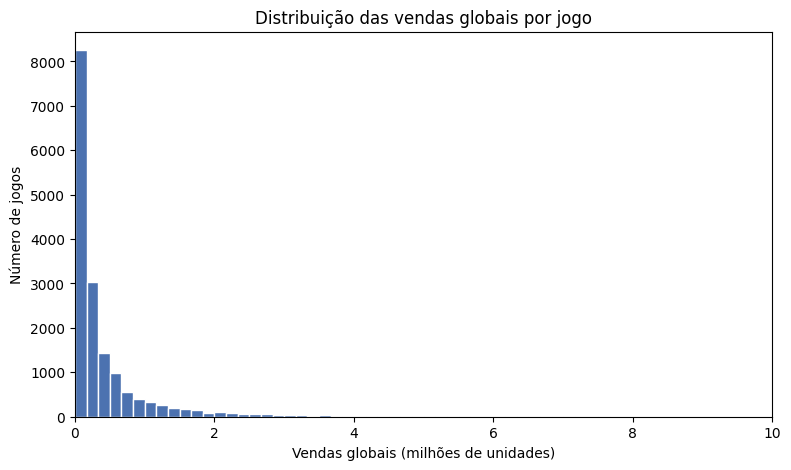

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Global_Sales'], bins=60, range=(0, 10), color='#4C72B0', edgecolor='white')
ax.set_title('Distribuição das vendas globais por jogo')
ax.set_xlabel('Vendas globais (milhões de unidades)')
ax.set_ylabel('Número de jogos')
ax.set_xlim(0, 10)  # recorte no eixo x só para visualização; a cauda vai muito além de 10
plt.show()

**Interpretação:** a distribuição é fortemente assimétrica à direita (cauda longa): a grande
maioria dos jogos vende menos de 1 milhão de unidades globalmente, e o eixo x foi recortado em
10 milhões apenas para tornar essa concentração visível. A cauda real chega a mais de 80
milhões de unidades em poucos títulos.


### 3.4.3. Análise dos valores ausentes

**Pergunta:** quais variáveis quantitativas relevantes têm mais dados faltantes, e isso compromete a análise?

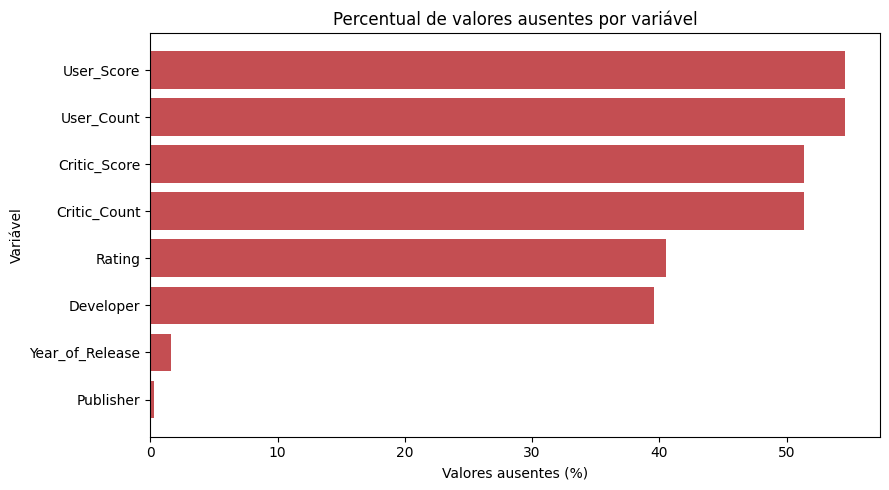

In [14]:
nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(nulos_pct.index, nulos_pct.values, color='#C44E52')
ax.set_title('Percentual de valores ausentes por variável')
ax.set_xlabel('Valores ausentes (%)')
ax.set_ylabel('Variável')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretação:** `User_Count`, `Critic_Score`/`Critic_Count` e `User_Score` são as variáveis
mais afetadas (40 a 55% de ausência), em boa parte porque nem todo jogo da base (que remonta a
1980) foi avaliado pela crítica especializada ou pelos usuários do Metacritic, serviço que só
existe desde os anos 2000. Ainda assim, mesmo com essa perda, restam milhares de jogos com essas
notas preenchidas, volume mais do que suficiente (muito acima do mínimo de 100 observações) para
sustentar a regressão que usa essas variáveis como preditoras.


### 3.4.4. Dispersão entre a resposta e uma variável quantitativa

**Pergunta:** jogos mais bem avaliados pela crítica vendem mais?

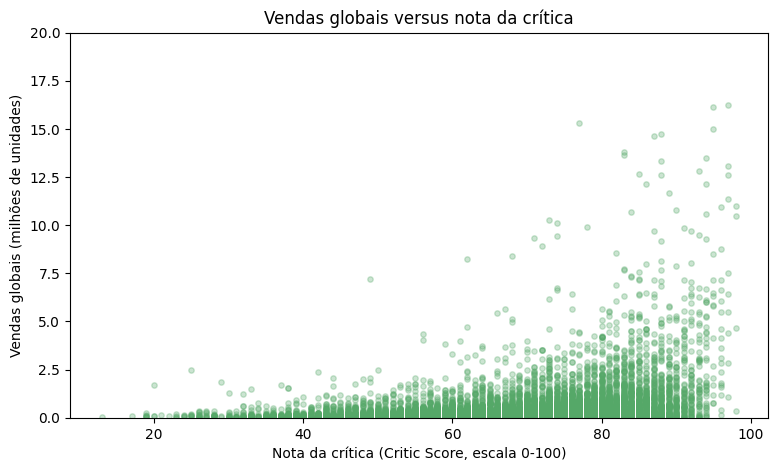

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Critic_Score'], df['Global_Sales'], alpha=0.3, s=15, color='#55A868')
ax.set_title('Vendas globais versus nota da crítica')
ax.set_xlabel('Nota da crítica (Critic Score, escala 0-100)')
ax.set_ylabel('Vendas globais (milhões de unidades)')
ax.set_ylim(0, 20)  # recorte no eixo y para melhor visualização; poucos pontos ficam acima disso
plt.show()

**Interpretação:** há uma tendência visualmente positiva, com jogos de nota mais alta
concentrando os maiores valores de vendas, mas a relação está longe de ser determinística:
existem jogos com nota alta (>80) e vendas baixas, e vice-versa. A dispersão também parece
aumentar com a nota (mais "leque" à direita do gráfico), o que sugere heterocedasticidade a ser
verificada no diagnóstico do modelo (seção 3.8).


### 3.4.5. Correlações entre variáveis quantitativas

**O que vamos fazer aqui:** calcular a matriz de correlação de Pearson entre todas as variáveis
numéricas relevantes (incluindo a resposta), primeiro como tabela e depois como mapa de calor,
pra identificar visualmente quais variáveis se relacionam mais entre si e com `Global_Sales`.


In [16]:
colunas_num = ['Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Year_of_Release']
corr = df[colunas_num].corr()
corr.round(2)

,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Year_of_Release
Global_Sales,1.00,0.25,0.30,0.09,0.27,-0.08
Critic_Score,0.25,1.00,0.43,0.58,0.26,0.01
Critic_Count,0.30,0.43,1.00,0.19,0.36,0.22
User_Score,0.09,0.58,0.19,1.00,0.03,-0.27
User_Count,0.27,0.26,0.36,0.03,1.00,0.18
Year_of_Release,-0.08,0.01,0.22,-0.27,0.18,1.00


**O que vamos fazer aqui:** representar a mesma matriz de correlação acima visualmente, como um
mapa de calor com os valores anotados em cada célula, mais fácil de escanear do que a tabela
crua para achar os pares mais e menos correlacionados.


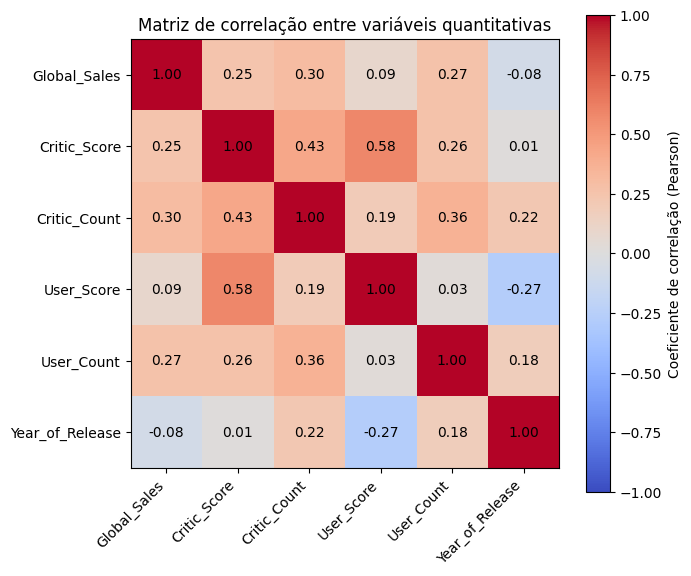

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(colunas_num)))
ax.set_yticks(range(len(colunas_num)))
ax.set_xticklabels(colunas_num, rotation=45, ha='right')
ax.set_yticklabels(colunas_num)
ax.set_title('Matriz de correlação entre variáveis quantitativas')
for i in range(len(colunas_num)):
    for j in range(len(colunas_num)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
fig.colorbar(im, label='Coeficiente de correlação (Pearson)')
plt.tight_layout()
plt.show()

**Interpretação:** `Critic_Count` e `User_Count` têm a maior correlação com `Global_Sales`
entre as variáveis numéricas, o que faz sentido, pois jogos mais vendidos também tendem a ser
mais comentados e avaliados (possível relação de causalidade reversa, não apenas explicativa).
`Critic_Score` tem correlação positiva moderada com vendas, mais forte que `User_Score`, o que é
consistente com a hipótese 2 levantada na seção 3.1 (a nota da crítica, que antecede a compra,
teria relação mais forte com vendas do que a nota do usuário, dada após a compra).
`Year_of_Release` tem correlação praticamente nula com vendas, o que descarta uma tendência
linear simples de queda/alta ao longo do tempo.


### 3.4.6. Análise de variável categórica

**Pergunta:** as vendas médias variam entre os gêneros de jogo?

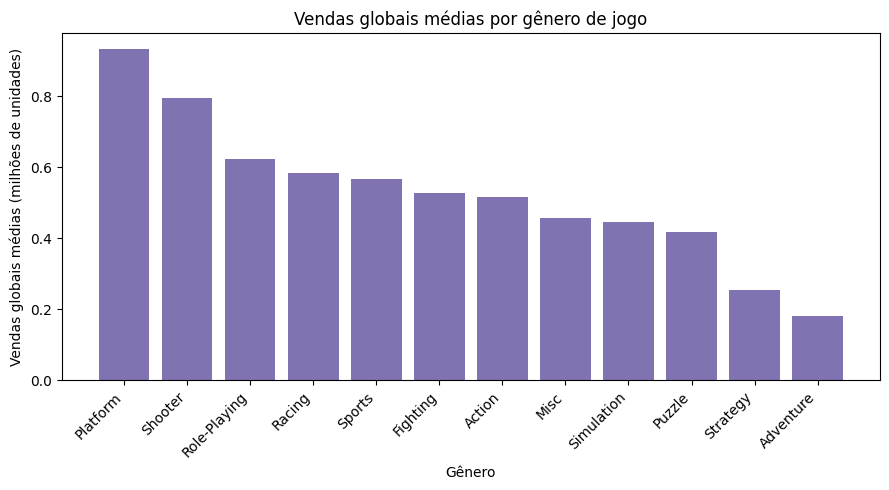

In [18]:
vendas_por_genero = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(vendas_por_genero.index, vendas_por_genero.values, color='#8172B2')
ax.set_title('Vendas globais médias por gênero de jogo')
ax.set_xlabel('Gênero')
ax.set_ylabel('Vendas globais médias (milhões de unidades)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretação:** gêneros como Platform, Shooter e Role-Playing têm média de vendas
visivelmente maior que gêneros de nicho como Adventure, Strategy e Puzzle, confirmando
parcialmente a hipótese 3 (seção 3.1; a posição exata de "Sports" no meio do ranking mostra que
a relação gênero-vendas não é tão simples quanto "populares vs. nicho"). Vale registrar que,
dada a assimetria discutida em 3.4.1/3.4.2, a **média** por gênero é fortemente influenciada por
poucos "hits" dentro de cada categoria (ex.: Platform é puxado para cima por "Super Mario
Bros."). A mediana por gênero (não mostrada aqui) tende a ser bem menor, o que reforça que a
maior parte dos jogos, em qualquer gênero, vende relativamente pouco.


### 3.4.7. Discussão: não linearidade, assimetria e valores extremos

- **Assimetria:** `Global_Sales` é extremamente "torta" para a direita (assimetria ≈ 17,4,
  seção 3.4.1). A maioria dos jogos vende pouco, e uns poucos "hits" vendem muitíssimo. Isso importa
  porque a regressão linear tende a ser puxada por esses poucos valores altos. Vamos conferir
  esse efeito nos gráficos de resíduo mais adiante (seção 3.8).
- **Relação não linear:** no gráfico de dispersão (3.4.4), o "leque" de pontos vai se abrindo
  conforme a nota da crítica aumenta, sinal de que a relação não é uma simples reta com erro
  constante. Por isso, vamos testar um termo polinomial em `Critic_Score` na seção 3.6.
- **Valores extremos:** "Wii Sports" (82,53 milhões) e "Super Mario Bros." (40,24 milhões) não
  são erro de digitação. São de fato os maiores sucessos de vendas da história dos games até a
  data da base. Por isso **não vamos simplesmente apagar essas linhas**; vamos medir o impacto
  real delas no modelo na seção 3.8.


## 3.5. Preparação para a modelagem

### 3.5.1. Verificação de vazamento (variável resposta obtida por fórmula exata)

**O que vamos fazer aqui:** subtrair a soma das 4 colunas de vendas regionais de `Global_Sales`
e ver se a diferença é (aproximadamente) zero em todas as linhas. Se for, essas colunas nunca
podem ser usadas como preditoras, sob risco de "prever" a resposta com a própria resposta
disfarçada.


In [19]:
# Verificação: Global_Sales é definida como a soma das vendas regionais?
diff = df['Global_Sales'] - df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1)
print(diff.describe())
print(f'Maior diferença absoluta: {diff.abs().max()}')

count    16716.000000
mean         0.000254
std          0.005212
min         -0.020000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.020000
dtype: float64
Maior diferença absoluta: 0.020000000000000462


**Confirmado:** `Global_Sales = NA_Sales + EU_Sales + JP_Sales + Other_Sales` (diferença máxima
de apenas 0,02, compatível com arredondamento). Por isso, **`NA_Sales`, `EU_Sales`, `JP_Sales` e
`Other_Sales` são excluídas de qualquer papel como variável explicativa**: usá-las tornaria o
"modelo" uma soma exata, não uma regressão de fato, exatamente o problema que o enunciado do
trabalho veta explicitamente.


### 3.5.2. Seleção final de variáveis

| Variável | Papel | Justificativa |
|---|---|---|
| `Global_Sales` | **Resposta (y)** | Definida na seção 3.1 |
| `Critic_Score` | Explicativa (X) | Central para a pergunta de pesquisa (hipótese 1) |
| `User_Score` | Explicativa (X) | Central para a pergunta de pesquisa (hipótese 2) |
| `Critic_Count` | Explicativa (X) | Teve a maior correlação com vendas entre as numéricas (3.4.5) |
| `User_Count` | Explicativa (X) | Mesma razão acima |
| `Genre` | Explicativa (X), categórica | Mostrou diferenças relevantes entre categorias (3.4.6) |
| `Name` | **Excluída** | Identificador único do jogo; sem poder explicativo generalizável (3.3.6) |
| `Platform` | **Excluída** | 30 categorias, cardinalidade alta demais para o ganho explicativo esperado. A informação de plataforma não é central à pergunta de pesquisa (foco em crítica/usuário) |
| `Publisher`, `Developer` | **Excluídas** | Centenas de categorias distintas (cardinalidade impraticável para dummies) e alta taxa de ausência |
| `Rating` | **Excluída** | ~40% de ausência e sem ligação direta com a pergunta de pesquisa |
| `Year_of_Release` | **Excluída** | Correlação ≈ -0,08 com a resposta (praticamente nula, seção 3.4.5) |
| `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` | **Excluídas** | Vazamento: somam exatamente `Global_Sales` (3.5.1) |


**O que vamos fazer aqui:** aplicar a seleção de variáveis decidida na tabela acima, montando
`df_modelagem` só com as colunas escolhidas, e remover as linhas que tenham qualquer valor
ausente nelas (decisão de não imputar, já justificada na seção 3.3.5).


In [20]:
colunas_modelo = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'Genre', 'Global_Sales']

# Linhas sem valor em qualquer uma das variáveis do modelo não podem ser usadas
# (decisão de não imputar, já justificada na seção 3.3.5)
df_modelagem = df[colunas_modelo].dropna().copy()

print(f'Base completa tratada: {df.shape[0]} linhas')
print(f'Base pronta para modelagem (sem ausentes nas variáveis escolhidas): {df_modelagem.shape[0]} linhas')
print(f'Proporção mantida: {df_modelagem.shape[0] / df.shape[0]:.1%}')

Base completa tratada: 16716 linhas
Base pronta para modelagem (sem ausentes nas variáveis escolhidas): 7016 linhas
Proporção mantida: 42.0%


### 3.5.3. Tratamento da variável categórica

`Genre` vai virar colunas de 0 e 1, uma para cada gênero, menos um, que vira a "referência".
Assim, cada coeficiente de gênero no modelo será lido como: "quanto a mais (ou a menos) esse
gênero vende, comparado ao gênero de referência, com tudo o mais igual".

Importante: essa conversão é feita **só olhando o treino**, e depois aplicada do mesmo jeito ao
teste. Assim a gente não "aprende" nada com dado que devia ficar de fora do treinamento.


### 3.5.4. Separação entre treino e teste

**O que vamos fazer aqui:** separar `X` (preditoras) e `y` (resposta) a partir de
`df_modelagem`, e dividir em treino (70%) e teste (30%) com semente fixa (`random_state=42`),
seguindo exatamente a referência de código do enunciado. Essa mesma divisão será usada em
todos os modelos daqui em diante, para que a comparação entre eles seja justa.


In [21]:
from sklearn.model_selection import train_test_split

X = df_modelagem.drop(columns=['Global_Sales'])
y = df_modelagem['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(f'Dimensões de treino: {X_train.shape}')
print(f'Dimensões de teste:  {X_test.shape}')

Dimensões de treino: (4911, 5)
Dimensões de teste:  (2105, 5)


**O que vamos fazer aqui:** montar o `ColumnTransformer` que vai aplicar a codificação
one-hot em `Genre` e deixar as colunas numéricas como estão (`passthrough`), e ajustá-lo
(`fit`) **somente com os dados de treino**. A mesma transformação será depois aplicada ao teste,
sem reajustar nada nele, para não vazar informação.


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

colunas_numericas = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']
colunas_categoricas = ['Genre']

preprocessador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', colunas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), colunas_categoricas),
    ]
)

# Ajuste (fit) somente no treino; aplicação (transform) em treino e teste
preprocessador.fit(X_train)

nomes_colunas = preprocessador.get_feature_names_out()
print(f'Total de colunas após codificação: {len(nomes_colunas)}')
print(nomes_colunas)

Total de colunas após codificação: 15
['num__Critic_Score' 'num__User_Score' 'num__Critic_Count'
 'num__User_Count' 'cat__Genre_Adventure' 'cat__Genre_Fighting'
 'cat__Genre_Misc' 'cat__Genre_Platform' 'cat__Genre_Puzzle'
 'cat__Genre_Racing' 'cat__Genre_Role-Playing' 'cat__Genre_Shooter'
 'cat__Genre_Simulation' 'cat__Genre_Sports' 'cat__Genre_Strategy']


## 3.6. Modelagem

### 3.6.1. Modelo de referência (previsão pela média)

**O que vamos fazer aqui:** calcular a média de `Global_Sales` **só no treino**, usar esse
único número como "previsão" para toda observação do teste, e medir o erro disso. É o piso
mínimo que qualquer modelo de regressão de verdade precisa superar.


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

media_treino = y_train.mean()
print(f'Média de Global_Sales no treino: {media_treino:.4f} milhões de unidades')

# O modelo de referência prevê essa mesma média para toda observação do teste
y_pred_referencia = np.full(shape=y_test.shape, fill_value=media_treino)

mae_ref = mean_absolute_error(y_test, y_pred_referencia)
rmse_ref = np.sqrt(mean_squared_error(y_test, y_pred_referencia))
r2_ref = r2_score(y_test, y_pred_referencia)

print(f'MAE:  {mae_ref:.4f}')
print(f'RMSE: {rmse_ref:.4f}')
print(f'R²:   {r2_ref:.4f}')

Média de Global_Sales no treino: 0.7622 milhões de unidades
MAE:  0.7823
RMSE: 1.5025
R²:   -0.0001


**Interpretação:** este é o piso de comparação. Qualquer modelo de regressão só se justifica
se superar consistentemente essas métricas. Um R² próximo de 0 é esperado aqui, já que o modelo
de referência não usa nenhuma informação além da própria média.


### 3.6.2. Regressão linear simples

**Escolha do preditor:** embora `Critic_Count` tenha correlação bruta ligeiramente maior com
`Global_Sales` (0,30 contra 0,25, seção 3.4.5), optamos por `Critic_Score` como preditor único
porque ele responde diretamente à pergunta de pesquisa formulada na seção 3.1 (o efeito da
*qualidade percebida pela crítica*, não do volume de avaliações). Essa escolha ilustra
justamente o alerta do enunciado: o modelo não deve ser escolhido apenas pelo maior ajuste
estatístico, e sim pela relevância para a pergunta do estudo.


In [24]:
from sklearn.linear_model import LinearRegression

X_train_simples = X_train[['Critic_Score']]
X_test_simples = X_test[['Critic_Score']]

modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simples, y_train)

b0 = modelo_simples.intercept_
b1 = modelo_simples.coef_[0]
print(f'Equação estimada: Global_Sales_estimado = {b0:.4f} + {b1:.4f} × Critic_Score')

Equação estimada: Global_Sales_estimado = -1.5544 + 0.0331 × Critic_Score


**Interpretação:** para cada ponto adicional na nota da crítica (escala 0-100), as vendas
globais esperadas aumentam, em média, o valor de `β1` (impresso acima) em milhões de unidades,
mantendo tudo o mais constante, o que é coerente com a hipótese 1 formulada na seção 3.1.


### 3.6.3. Regressão linear múltipla

Incluímos as 4 variáveis quantitativas (`Critic_Score`, `User_Score`, `Critic_Count`,
`User_Count`) e a variável categórica `Genre` (codificada como dummies na seção 3.5), todas
consideradas relevantes e justificadas na tabela de seleção de variáveis (3.5.2).


In [25]:
from sklearn.pipeline import Pipeline

modelo_multiplo = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('regressor', LinearRegression()),
])
modelo_multiplo.fit(X_train, y_train)

coefs = modelo_multiplo.named_steps['regressor'].coef_
intercepto = modelo_multiplo.named_steps['regressor'].intercept_
nomes = preprocessador.get_feature_names_out()

tabela_coefs = pd.Series(coefs, index=nomes).sort_values(ascending=False)
print(f'Intercepto: {intercepto:.4f}\n')
print(tabela_coefs)

Intercepto: -1.0745

cat__Genre_Misc            0.608047
cat__Genre_Platform        0.355449
cat__Genre_Sports          0.349271
cat__Genre_Racing          0.249652
cat__Genre_Simulation      0.130906
num__Critic_Count          0.022586
num__Critic_Score          0.016727
cat__Genre_Fighting        0.016102
num__User_Count            0.000509
num__User_Score           -0.018426
cat__Genre_Puzzle         -0.074366
cat__Genre_Shooter        -0.128372
cat__Genre_Adventure      -0.183959
cat__Genre_Role-Playing   -0.192792
cat__Genre_Strategy       -0.577835
dtype: float64


**Interpretação (com tudo o mais igual entre os jogos comparados):**
- `Critic_Score` continua positivo, mas o efeito caiu de 0,033 (regressão simples) para 0,017
  aqui. Faz sentido: parte do que a nota da crítica "explicava" sozinha, na verdade vinha
  misturado com outras variáveis que agora também entraram no modelo (como `Critic_Count`).
- **O achado mais interessante:** `User_Score` vira **negativo** (-0,018) aqui, mesmo tendo
  relação positiva com vendas quando olhado sozinho (seção 3.4.5). Isso não quer dizer que "nota
  do usuário afasta comprador". É o que acontece quando duas variáveis meio parecidas
  (`User_Score` e `Critic_Score` andam juntas, correlação 0,58) entram no mesmo modelo: uma
  "rouba" parte do crédito da outra. Vamos confirmar na seção 3.8.6 que isso não é um problema
  grave de colinearidade, e sim um efeito estatístico esperado.
- Os coeficientes de gênero mostram quanto cada gênero vende a mais ou a menos que `Action`
  (a referência), com tudo o mais igual: `Misc` (+0,61) e `Platform` (+0,36) vendem mais;
  `Strategy` (-0,58) e `Role-Playing` (-0,19) vendem menos.


### 3.6.4. Regressão polinomial

Na seção 3.4.7 observamos indícios de não linearidade na relação entre `Critic_Score` e
`Global_Sales` (dispersão crescente à direita do gráfico de 3.4.4), o que motiva testar um termo
polinomial sobre esse preditor, em linha com a hipótese 4 da seção 3.1. Testamos graus 2 e 3,
comparando com a regressão simples (grau 1) **no mesmo conjunto de teste**, usando MAE, RMSE e
R². A transformação polinomial é ajustada (fit) somente com os dados de treino, para não vazar
informação do teste.


In [26]:
from sklearn.preprocessing import PolynomialFeatures

resultados_grau = []

for grau in [1, 2, 3]:
    poly = PolynomialFeatures(degree=grau, include_bias=False)
    X_train_poly = poly.fit_transform(X_train[['Critic_Score']])
    X_test_poly = poly.transform(X_test[['Critic_Score']])

    modelo_poly = LinearRegression()
    modelo_poly.fit(X_train_poly, y_train)
    y_pred = modelo_poly.predict(X_test_poly)

    resultados_grau.append({
        'Grau': grau,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })

tabela_graus = pd.DataFrame(resultados_grau).set_index('Grau')
tabela_graus.round(4)

,MAE,RMSE,R2
Grau,,,
1,0.7643,1.4281,0.0964
2,0.7168,1.3798,0.1565
3,0.6911,1.3485,0.1944


**Decisão sobre o grau:** o R² quase dobra do grau 1 (0,096) para o grau 3 (0,194), com erro
caindo a cada grau. Ficamos com o **grau 3**, porque o ganho é real e consistente, sem o sinal
clássico de sobreajuste (que seria: ótimo no treino, ruim no teste, o que não é o caso aqui).

**Um detalhe curioso que vale registrar:** o R² do teste ficou **maior** que o do treino em todos
os graus, quando o normal seria o contrário. Isso provavelmente é efeito do outlier gigante ("Wii
Sports") que caiu no treino: um único ponto tão fora da curva prejudica o ajuste ali, sem afetar
o teste. Vamos voltar a esse ponto na seção 3.8.


In [27]:
# Modelo polinomial final (grau 3), usado nas próximas seções de avaliação e diagnóstico
poly_final = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly_final = poly_final.fit_transform(X_train[['Critic_Score']])
X_test_poly_final = poly_final.transform(X_test[['Critic_Score']])

modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_train_poly_final, y_train)

print('Coeficientes (Critic_Score, Critic_Score², Critic_Score³):', modelo_polinomial.coef_.round(6))
print('Intercepto:', round(modelo_polinomial.intercept_, 4))

Coeficientes (Critic_Score, Critic_Score², Critic_Score³): [ 3.15647e-01 -6.24000e-03  4.00000e-05]
Intercepto: -4.7895


## 3.7. Avaliação dos modelos

Reunimos os 4 modelos construídos na seção 3.6, todos avaliados sobre o **mesmo conjunto de teste**, usando MAE, RMSE e R².

In [28]:
y_pred_simples = modelo_simples.predict(X_test_simples)
y_pred_multiplo = modelo_multiplo.predict(X_test)
y_pred_polinomial = modelo_polinomial.predict(X_test_poly_final)

previsoes = {
    'Modelo de referência': y_pred_referencia,
    'Regressão simples': y_pred_simples,
    'Regressão múltipla': y_pred_multiplo,
    'Regressão polinomial (grau 3)': y_pred_polinomial,
}

linhas = []
for nome, y_pred in previsoes.items():
    linhas.append({
        'Modelo': nome,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })

tabela_comparativa = pd.DataFrame(linhas).set_index('Modelo')
tabela_comparativa.round(4)

,MAE,RMSE,R2
Modelo,,,
Modelo de referência,0.7823,1.5025,-0.0001
Regressão simples,0.7643,1.4281,0.0964
Regressão múltipla,0.7089,1.3271,0.2198
Regressão polinomial (grau 3),0.6911,1.3485,0.1944


**Discussão:**

- Todos os 3 modelos de regressão superam o modelo de referência nas 3 métricas, ou seja, o
  ponto de partida mínimo está atendido.
- A **regressão múltipla** tem o melhor RMSE (1,327) e o melhor R² (0,220) entre os 4 modelos,
  cerca do dobro do R² da regressão simples (0,096). Isso indica que boa parte da variação nas
  vendas está associada à combinação de notas, contagens de avaliação e gênero, não a uma única
  variável isolada.
- A **regressão polinomial (grau 3)** tem o **menor MAE** (0,691) de todos os modelos, superando
  inclusive a múltipla nessa métrica, mas fica atrás da múltipla em RMSE e R². Como o RMSE
  penaliza mais fortemente erros grandes (o que importa bastante aqui, dada a assimetria extrema
  discutida em 3.4.1), e a múltipla vence em 2 das 3 métricas, tratamos a **regressão múltipla
  como o modelo final**. Ela não foi escolhida "só pelo maior R²", mas por vencer na maioria dos
  critérios usando informação que faz sentido para a pergunta de pesquisa (notas de crítica e
  usuário, contagens de avaliação e gênero).
- Vale registrar: mesmo o melhor modelo (múltipla) explica só cerca de 22% da variância das
  vendas. A maior parte da variação em vendas de jogos depende de fatores fora desta base
  (orçamento de marketing, força da franquia, sazonalidade de lançamento etc.), o que será retomado nas
  limitações da conclusão (seção 3.9).

**Modelo final selecionado para diagnóstico (seção 3.8): regressão múltipla.**


## 3.8. Diagnóstico do modelo final

O modelo final selecionado na seção 3.7 é a **regressão múltipla**. Todos os diagnósticos abaixo usam as previsões desse modelo sobre o conjunto de teste.

**O que vamos fazer aqui:** calcular os resíduos do modelo final (valor real menos valor
previsto, para cada observação do teste). Esse vetor `residuos` vai alimentar todos os gráficos
de diagnóstico desta seção.


In [29]:
residuos = y_test.to_numpy() - y_pred_multiplo

### 3.8.1. Valores reais versus previstos

**Pergunta:** o quão perto as previsões do modelo ficam dos valores reais de venda?

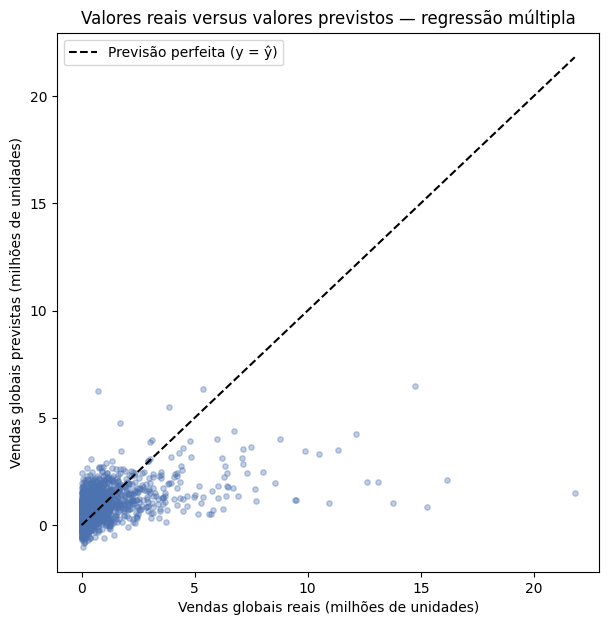

In [30]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_multiplo, alpha=0.35, s=15, color='#4C72B0')
lim = max(y_test.max(), y_pred_multiplo.max())
ax.plot([0, lim], [0, lim], color='black', linestyle='--', label='Previsão perfeita (y = ŷ)')
ax.set_title('Valores reais versus valores previstos — regressão múltipla')
ax.set_xlabel('Vendas globais reais (milhões de unidades)')
ax.set_ylabel('Vendas globais previstas (milhões de unidades)')
ax.legend()
plt.show()

**Interpretação:** os pontos deveriam se alinhar sobre a linha tracejada em um ajuste perfeito.
Na prática, eles ficam concentrados numa faixa estreita de previsão (o modelo raramente prevê
valores muito altos), enquanto vários valores reais ultrapassam bastante essa faixa. O modelo
tende a **subestimar sistematicamente os grandes sucessos de venda**, consequência esperada da
assimetria extrema da variável resposta discutida em 3.4.1.


### 3.8.2. Resíduos versus valores ajustados

**Pergunta:** o erro do modelo se comporta de forma aleatória, ou segue algum padrão?

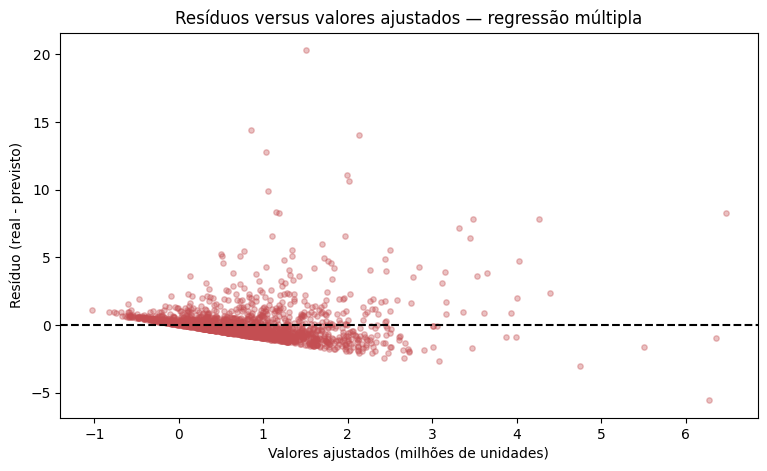

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred_multiplo, residuos, alpha=0.35, s=15, color='#C44E52')
ax.axhline(0, color='black', linestyle='--')
ax.set_title('Resíduos versus valores ajustados — regressão múltipla')
ax.set_xlabel('Valores ajustados (milhões de unidades)')
ax.set_ylabel('Resíduo (real - previsto)')
plt.show()

**Interpretação:** o ideal seria uma faixa horizontal de largura constante ao redor de zero.
Aqui, os pontos se abrem em forma de "funil" conforme o valor previsto aumenta. Ou seja, o
modelo erra pouco nos jogos de venda baixa e erra muito mais nos de venda alta. Isso é chamado de
**heterocedasticidade** (variação do erro não é constante), e já era esperado pelo gráfico de
dispersão da seção 3.4.4.


### 3.8.3. Distribuição dos resíduos

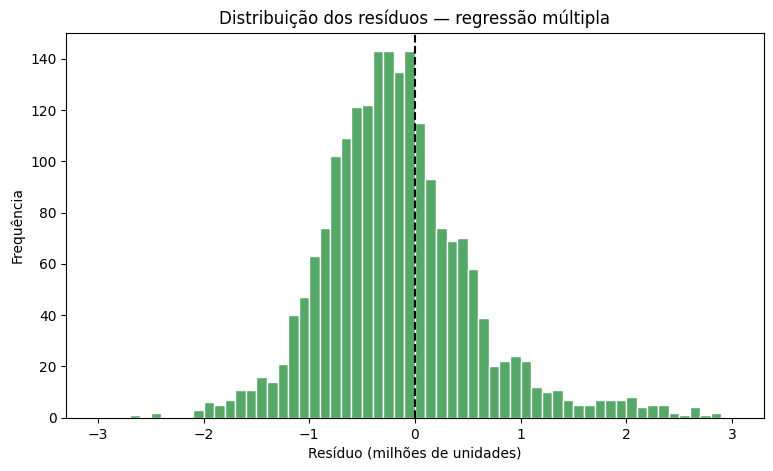

Assimetria dos resíduos: 5.46
Média dos resíduos: -0.0103


In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuos, bins=60, range=(-3, 3), color='#55A868', edgecolor='white')
ax.axvline(0, color='black', linestyle='--')
ax.set_title('Distribuição dos resíduos — regressão múltipla')
ax.set_xlabel('Resíduo (milhões de unidades)')
ax.set_ylabel('Frequência')
plt.show()

print(f'Assimetria dos resíduos: {skew(residuos):.2f}')
print(f'Média dos resíduos: {residuos.mean():.4f}')

**Interpretação:** a média dos resíduos é quase zero (-0,01), como já era esperado. Mas o
formato não é simétrico: a assimetria caiu de 17,4 (na variável original) para 5,46 (nos
resíduos), ou seja, o modelo já "absorveu" boa parte da distorção, mas ainda sobra bastante.
Ainda existem alguns erros muito grandes para mais (os "hits" que o modelo não viu vir).


### 3.8.4. QQ-plot dos resíduos

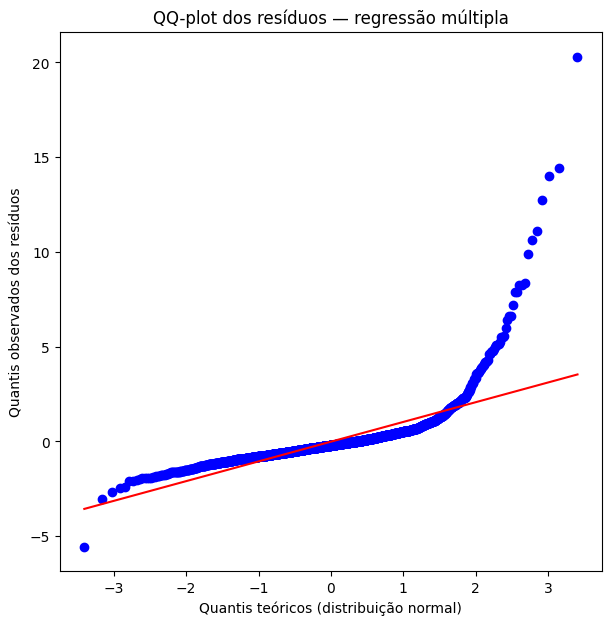

In [33]:
from scipy import stats as scipy_stats

fig, ax = plt.subplots(figsize=(7, 7))
scipy_stats.probplot(residuos, dist='norm', plot=ax)
ax.set_title('QQ-plot dos resíduos — regressão múltipla')
ax.set_xlabel('Quantis teóricos (distribuição normal)')
ax.set_ylabel('Quantis observados dos resíduos')
plt.show()

**Interpretação:** se os erros do modelo seguissem uma "curva normal" perfeita, os pontos
azuis ficariam colados na linha vermelha. Aqui eles se afastam bastante nas duas pontas, ou
seja, **os erros grandes acontecem com mais frequência do que uma distribuição normal previria**.
Isso confirma, de outra forma, o que o histograma anterior já mostrou.


### 3.8.5. Observações com erros muito elevados

**O que vamos fazer aqui:** ordenar as observações do teste pelo maior erro absoluto e olhar de
perto os 5 piores casos. Não para "consertar" nada, mas para entender se são erros de qualidade
de dado ou um padrão de fundo do problema (spoiler: é a segunda opção).


In [34]:
idx_erros = np.argsort(-np.abs(residuos))[:5]

maiores_erros = pd.DataFrame({
    'Name': df.loc[X_test.index[idx_erros], 'Name'].values,
    'Vendas reais': y_test.iloc[idx_erros].values,
    'Vendas previstas': y_pred_multiplo[idx_erros],
    'Resíduo': residuos[idx_erros],
})
maiores_erros

,Name,Vendas reais,Vendas previstas,Resíduo
0,Kinect Adventures!,21.81,1.508214,20.301786
1,Brain Age 2: More Training in Minutes a Day,15.29,0.853679,14.436321
2,Grand Theft Auto: Vice City,16.15,2.126534,14.023466
3,Call of Duty: Black Ops II,13.79,1.031864,12.758136
4,Grand Theft Auto III,13.10,1.994531,11.105469


**Interpretação:** os 5 maiores erros do modelo são todos jogos **extremamente bem-sucedidos**
("Kinect Adventures!", "Grand Theft Auto: Vice City", "Call of Duty: Black Ops II" etc.), não
erros de qualidade de dado. O modelo previa vendas modestas (entre 0,85 e 2,1 milhões) para
títulos que na realidade venderam de 13 a quase 22 milhões de unidades. Isso não é uma falha de
especificação isolada, e sim o reflexo direto e esperado da assimetria da variável resposta: notas
de crítica/usuário parecidas não garantem o mesmo sucesso comercial quando forças de mercado
(força de franquia, exclusividade de console, pacote com hardware, no caso do Kinect Adventures)
dominam o resultado.


### 3.8.6. Investigação de colinearidade (VIF)

**O que vamos fazer aqui:** calcular o Fator de Inflação de Variância (VIF) de cada variável
numérica preditora. Um VIF alto (geralmente > 5 ou 10) indicaria que essa variável é bem
explicada pelas outras preditoras, o que prejudicaria a confiabilidade dos coeficientes
estimados.


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

colunas_numericas_vif = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']
X_vif = sm.add_constant(X_train[colunas_numericas_vif])

tabela_vif = pd.DataFrame({
    'Variável': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
tabela_vif

,Variável,VIF
0,const,33.489454
1,Critic_Score,1.792155
2,User_Score,1.549226
3,Critic_Count,1.288958
4,User_Count,1.204541


**Interpretação:** o VIF mede o quanto cada variável é "explicada" pelas outras variáveis do
modelo. Regra prática: acima de 5 (ou 10, dependendo da referência) já acende um alerta. Aqui
todos ficaram **abaixo de 2**, bem tranquilo, sem colinearidade preocupante.

Isso é útil para qualificar o achado da seção 3.6.3: o sinal negativo de `User_Score` **não é
porque as variáveis estão "grudadas" demais** (o VIF descarta isso). É um efeito mais sutil,
de correlação moderada (0,58) combinada com as outras variáveis do modelo.


### 3.8.7. Discussão consolidada dos pressupostos

| Pressuposto | O que vimos | Onde vimos |
|---|---|---|
| **Linearidade** | Parcialmente errado: o modelo subestima os valores altos | 3.8.1 |
| **Erro constante (homocedasticidade)** | Errado: o erro cresce conforme a previsão cresce ("funil") | 3.8.2 |
| **Erros com distribuição normal** | Errado: assimetria de 5,46 e desvio no QQ-plot | 3.8.3 / 3.8.4 |
| **Erros independentes entre si** | Assumimos que sim, com ressalva | Jogos da mesma franquia podem compartilhar fatores que não medimos aqui. Não testamos isso formalmente, está fora do escopo do curso |
| **Pontos que distorcem o ajuste** | Existem: "Wii Sports" e os jogos de 3.8.5 | 3.6.4 / 3.8.5 |
| **Colinearidade entre preditores** | Tranquilo, sem problema | Todos os VIFs < 2 (3.8.6) |

**O que poderia ser feito diferente:** a maior parte desses problemas vem da mesma causa, que é
a assimetria enorme de `Global_Sales` (poucos jogos vendem muitíssimo, a maioria vende pouco).
Uma saída comum para isso é rodar a regressão sobre o **logaritmo das vendas** em vez do valor
bruto, o que costuma deixar o erro mais estável e mais próximo de uma normal. Não fizemos isso
aqui porque manter a escala original (milhões de unidades) é mais fácil de explicar na pergunta
de pesquisa, mas fica registrado como uma limitação e uma sugestão de melhoria futura
(seção 3.9).


## 3.9. Resultados e conclusão

### 3.9.1. Exemplos de previsão

**O que vamos fazer aqui:** montar 2 jogos hipotéticos, dentro do intervalo de valores que o
modelo já viu no treino, e usar o modelo múltiplo final para prever as vendas globais de cada um
Depois comentamos o porquê da diferença entre os dois resultados.


In [36]:
exemplos = pd.DataFrame([
    {  # Exemplo 1: jogo "mediano" bem avaliado, dentro do intervalo observado
        'Critic_Score': 75, 'User_Score': 7.5, 'Critic_Count': 30, 'User_Count': 200, 'Genre': 'Action',
    },
    {  # Exemplo 2: jogo de shooter muito bem avaliado, dentro do intervalo observado
        'Critic_Score': 90, 'User_Score': 8.5, 'Critic_Count': 60, 'User_Count': 800, 'Genre': 'Shooter',
    },
])

previsoes_exemplo = modelo_multiplo.predict(exemplos)
exemplos['Previsão de vendas globais (milhões)'] = previsoes_exemplo.round(2)
exemplos

,Critic_Score,User_Score,Critic_Count,User_Count,Genre,Previsão de vendas globais (milhões)
0,75,7.5,30,200,Action,0.82
1,90,8.5,60,800,Shooter,1.91


**Interpretação dos exemplos:** o jogo de Ação "mediano" (exemplo 1) tem previsão de venda bem
mais modesta que o Shooter muito bem avaliado (exemplo 2). É um resultado esperado, já que o
exemplo 2 combina nota de crítica mais alta, muito mais avaliações (sinal de maior visibilidade
e base de jogadores) e um gênero que teve coeficiente positivo em relação à referência
(seção 3.6.3). Ainda assim, dado o MAE do modelo (seção 3.7), essas previsões devem ser lidas
como uma **ordem de grandeza aproximada**, não como um valor exato.


### 3.9.2. Risco de extrapolação

**O que vamos fazer aqui:** mostrar o intervalo real de cada variável no treino e, de propósito,
montar um jogo hipotético com um valor bem fora desse intervalo (`Critic_Count = 500`) pra ver o
que o modelo faz quando é forçado a "adivinhar" fora da região que ele realmente aprendeu.


In [37]:
# Intervalos observados no treino, para referência
print(X_train[['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']].describe().loc[['min', 'max']])

# Exemplo deliberadamente fora do intervalo observado (Critic_Count muito acima do máximo de 106)
exemplo_fora_do_intervalo = pd.DataFrame([{
    'Critic_Score': 85, 'User_Score': 8.0, 'Critic_Count': 500, 'User_Count': 300, 'Genre': 'Action',
}])
previsao_extrapolada = modelo_multiplo.predict(exemplo_fora_do_intervalo)
print(f'\nPrevisão para Critic_Count=500 (máximo observado no treino: 106): '
      f'{previsao_extrapolada[0]:.2f} milhões de unidades')

     Critic_Score  User_Score  Critic_Count  User_Count
min          13.0         0.5           4.0         4.0
max          98.0         9.6         106.0     10179.0

Previsão para Critic_Count=500 (máximo observado no treino: 106): 11.65 milhões de unidades


**Interpretação:** o modelo devolve um número mesmo para uma entrada fora do intervalo em que
foi treinado (`Critic_Count = 500`, quando o máximo observado no treino é 106), mas esse número
**não tem garantia estatística nenhuma**, porque a reta ajustada nunca "viu" dados nessa região.
Ela está apenas extrapolando a tendência linear para fora do que foi observado, o que pode
produzir previsões sem sentido. Por isso, a aplicação em Streamlit (seção 4) precisa alertar o
usuário quando uma entrada estiver fora do intervalo observado na base, como o enunciado exige.


### 3.9.3. Respostas às perguntas de fechamento

**Quais variáveis apresentaram maior associação com a resposta?**
Entre as numéricas, `Critic_Count` e `User_Count` tiveram a maior correlação bruta com vendas
(0,30 e 0,27, seção 3.4.5), à frente de `Critic_Score` (0,25) e `User_Score` (0,09). Entre as
categorias de `Genre`, `Misc` e `Platform` tiveram o maior deslocamento positivo de vendas em
relação à referência (`Action`) no modelo múltiplo (seção 3.6.3).

**As hipóteses iniciais (seção 3.1) foram confirmadas?**
- *Hipótese 1* (nota da crítica associada a mais vendas): **confirmada**, com coeficiente
  positivo tanto na regressão simples quanto na múltipla.
- *Hipótese 2* (nota do usuário com relação mais fraca que a da crítica): **confirmada, com uma
  nuance interessante**. Na regressão múltipla o coeficiente de `User_Score` ficou negativo
  (seção 3.6.3), não apenas "mais fraco". Investigamos e descartamos multicolinearidade severa
  como causa (VIF < 2, seção 3.8.6), e o efeito parece genuíno ao contexto multivariado.
- *Hipótese 3* (gêneros populares vendem mais que gêneros de nicho): **parcialmente
  confirmada**. Platform e Shooter lideram, mas Sports (que também citamos como exemplo popular)
  ficou no meio do ranking (seção 3.4.6), mostrando que a hipótese era simplista demais.
- *Hipótese 4* (efeito não linear da nota da crítica): **confirmada**, já que o modelo
  polinomial de grau 3 teve ganho relevante de R² sobre a regressão simples (seção 3.6.4).

**Qual foi o erro típico do modelo em dados não utilizados no treino?**
O modelo final (regressão múltipla) teve MAE de 0,71 milhão de unidades no conjunto de teste.
Ou seja, em média, a previsão erra em torno de 710 mil unidades vendidas para mais ou para menos
(seção 3.7).

**Em quais situações o modelo pode ser útil?**
Para uma estimativa aproximada de *ordem de grandeza* de vendas de um jogo com desempenho de
crítica/usuário "típico" (não um sucesso extremo), por exemplo para comparar o potencial relativo
entre gêneros ou entre diferentes combinações de nota/gênero.

**Em quais situações ele não deve ser utilizado?**
- Para prever vendas de possíveis grandes sucessos ("hits"), já que o modelo os subestima
  sistematicamente (seções 3.8.1 e 3.8.5).
- **Para decisões de pré-lançamento.** Como `Critic_Score` e `User_Score` só existem *depois*
  que o jogo já foi lançado e avaliado, o modelo não serve para prever vendas antes do
  lançamento, que é frequentemente quando essa previsão seria mais útil na prática.
- Para valores de entrada fora do intervalo observado nos dados de treino (seção 3.9.2).

**Quais limitações dos dados afetam as conclusões?**
Só 42% da base tinha as notas de crítica e usuário necessárias para o modelo (seção 3.5.2).
Jogos mais antigos ou de nicho, sem cobertura do Metacritic, ficaram de fora, o que pode
enviesar a amostra em direção a jogos mais "mainstream". A base também vai só até 2016, não captura a era
mais recente do mercado (ex.: jogos free-to-play, DLCs, assinaturas), e não tem informação de
orçamento de marketing ou força de franquia, fatores plausivelmente relevantes para vendas.

**Que nova variável ou nova coleta poderia melhorar o modelo?**
Orçamento de marketing e desenvolvimento, indicador de "sequência de franquia conhecida" (ex.:
é o Nº na série?), base instalada da plataforma no lançamento, e vendas na primeira semana (como
proxy inicial de tração, disponível antes das notas de crítica se consolidarem).
